---
date: "2026-07-20"
date-modified: last-modified
format:
  html:
    toc: true
---


# Chi-Square Distribution

## 1\. Definition and Construction

The **Chi-Square distribution** ($\chi^2$) is one of the most widely used continuous probability distributions in statistical inference, particularly in hypothesis testing and confidence interval estimation for population variances. It arises naturally as the distribution of the sum of squared independent standard Normal random variables.

::: {#def-chi-square}
## Chi-Square Distribution
Let $Z_1, Z_2, \dots, Z_n$ be independent and identically distributed ([i.i.d.](independence-of-rvs.ipynb)) [standard Normal random variables](normal-distribution.ipynb), where $Z_i \sim \mathcal{N}(0, 1)$. Define the random variable $V$ as the sum of their squares:

$$
V = \sum_{i=1}^n Z_i^2 = Z_1^2 + Z_2^2 + \dots + Z_n^2
$$

Then $V$ follows a **Chi-Square distribution with $n$ degrees of freedom**, denoted:

$$
V \sim \chi^2(n)
$$

The positive integer parameter $n$ represents the **degrees of freedom**, which counts the number of independent squared standard Normal variables being summed.
:::

::: {.callout-note}
## Intuition: Degrees of Freedom
Each squared standard Normal variable $Z_i^2$ contributes a non-negative random quantity to the sum. The parameter $n$ tracks the number of independent pieces of information (or dimensions) contributing to the total squared distance from the origin in $n$-dimensional Euclidean space.
:::


## 2\. Relationship to the Gamma Distribution

A fundamental bridge in probability theory connects the Chi-Square distribution directly to the [Gamma Distribution](gamma-function-and-distribution.ipynb). Specifically, the Chi-Square distribution is a special case of the Gamma distribution.

::: {#prp-chi-square-one}
## Chi-Square with 1 Degree of Freedom
A Chi-Square random variable with $1$ degree of freedom is exactly a Gamma random variable with shape parameter $\alpha = 1/2$ and rate parameter $\lambda = 1/2$ (or scale $\beta = 2$):

$$
\chi^2(1) \equiv \text{Gamma}\left(\frac{1}{2}, \frac{1}{2}\right)
$$
:::

::: {.callout-tip collapse="true"}
## Proof that $\chi^2(1)$ is $\text{Gamma}(1/2, 1/2)$
Let $V_1 = Z_1^2$, where $Z_1 \sim \mathcal{N}(0, 1)$. We find the probability density function (PDF) of $V_1$ by differentiating its cumulative distribution function (CDF).

Since $V_1 \ge 0$, for any $v \le 0$, $F_{V_1}(v) = P(V_1 \le v) = 0$.

For $v > 0$, we express the event $Z_1^2 \le v$ in terms of $Z_1$:

$$
\begin{aligned}
F_{V_1}(v) &= P(Z_1^2 \le v) \\
&= P(-\sqrt{v} \le Z_1 \le \sqrt{v}) \\
&= \Phi(\sqrt{v}) - \Phi(-\sqrt{v})
\end{aligned}
$$

By the tail symmetry of the standard Normal CDF, $\Phi(-z) = 1 - \Phi(z)$, so:

$$
F_{V_1}(v) = 2\Phi(\sqrt{v}) - 1
$$

Differentiating with respect to $v$ using the chain rule gives the PDF $f_{V_1}(v)$:

$$
\begin{aligned}
f_{V_1}(v) &= \frac{d}{dv} [2\Phi(\sqrt{v}) - 1] \\
&= 2 \varphi(\sqrt{v}) \cdot \frac{d}{dv}(\sqrt{v}) \\
&= 2 \left( \frac{1}{\sqrt{2\pi}} e^{-v/2} \right) \cdot \frac{1}{2\sqrt{v}} \\
&= \frac{1}{\sqrt{2\pi}} v^{-1/2} e^{-v/2}
\end{aligned}
$$

Recall that $\Gamma(1/2) = \sqrt{\pi}$. Substituting $\sqrt{2\pi} = \Gamma(1/2) \cdot 2^{1/2}$, we obtain:

$$
f_{V_1}(v) = \frac{(1/2)^{1/2}}{\Gamma(1/2)} v^{\frac{1}{2}-1} e^{-v/2}, \quad v > 0
$$

This matches the exact PDF definition of the $\text{Gamma}(\alpha, \lambda)$ distribution with shape parameter $\alpha = 1/2$ and rate parameter $\lambda = 1/2$. $\blacksquare$
:::

::: {#thm-chi-square-gamma}
## General Chi-Square as a Gamma Distribution
For any positive integer $n$:

$$
\chi^2(n) \equiv \text{Gamma}\left(\frac{n}{2}, \frac{1}{2}\right)
$$
:::

::: {.callout-tip collapse="true"}
## Proof of $\chi^2(n) = \text{Gamma}(n/2, 1/2)$ via Moment Generating Functions
We use the unique characterization property of [Moment Generating Functions](moment-generating-functions.ipynb).

**Step 1:** Find the MGF of $V_1 = Z_1^2 \sim \chi^2(1)$.
By Definition and the Law of the Unconscious Statistician ([LOTUS]()):

$$
\begin{aligned}
M_{V_1}(t) &= E[e^{t Z_1^2}] \\
&= \int_{-\infty}^{\infty} e^{t z^2} \frac{1}{\sqrt{2\pi}} e^{-z^2/2} dz \\
&= \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{\infty} \exp\left( -\frac{z^2}{2}(1 - 2t) \right) dz
\end{aligned}
$$

For $t < 1/2$, let $u = z \sqrt{1 - 2t}$, so $du = \sqrt{1 - 2t} \, dz$:

$$
\begin{aligned}
M_{V_1}(t) &= \frac{1}{\sqrt{1 - 2t}} \left( \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{\infty} e^{-u^2/2} du \right) \\
&= (1 - 2t)^{-1/2}, \quad \text{for } t < \frac{1}{2}
\end{aligned}
$$

**Step 2:** Find the MGF of $V = \sum_{i=1}^n Z_i^2 \sim \chi^2(n)$.
Because $Z_1^2, \dots, Z_n^2$ are mutually independent, the MGF of their sum equals the product of their individual MGFs:

$$
\begin{aligned}
M_V(t) &= \prod_{i=1}^n M_{Z_i^2}(t) \\
&= \prod_{i=1}^n (1 - 2t)^{-1/2} \\
&= (1 - 2t)^{-n/2}, \quad \text{for } t < \frac{1}{2}
\end{aligned}
$$

This formula $(1 - 2t)^{-n/2}$ is precisely the MGF of a Gamma random variable with shape parameter $\alpha = n/2$ and rate parameter $\lambda = 1/2$. By the uniqueness theorem of MGFs, $V \sim \text{Gamma}(n/2, 1/2)$. $\blacksquare$
:::


## 3\. PDF, Mean, and Variance

Using the equivalence established above between $\chi^2(n)$ and $\text{Gamma}(n/2, 1/2)$, we can state the probability density function and establish exact formulas for the [Expectation](expectation.ipynb) and [Variance](variance.ipynb).

### 3.1\. Probability Density Function
For $V \sim \chi^2(n)$, the PDF is given by:

$$
f_V(v) = \frac{(1/2)^{n/2}}{\Gamma(n/2)} v^{\frac{n}{2}-1} e^{-v/2}, \quad v > 0
$$

and $f_V(v) = 0$ for $v \le 0$.

### 3.2\. Mean and Variance

::: {#thm-chi-square-moments}
## Mean and Variance of Chi-Square
Let $V \sim \chi^2(n)$. Then:

1. $E[V] = n$
2. $\text{Var}(V) = 2n$
:::

::: {.callout-tip collapse="true"}
## Proof of Expectation and Variance
**Part 1: Expectation**
Using the definition $V = \sum_{i=1}^n Z_i^2$ and the linearity of expectation:

$$
\begin{aligned}
E[V] &= E\left[ \sum_{i=1}^n Z_i^2 \right] \\
&= \sum_{i=1}^n E[Z_i^2]
\end{aligned}
$$

Since $Z_i \sim \mathcal{N}(0, 1)$, we know $E[Z_i] = 0$ and $\text{Var}(Z_i) = 1$. Thus, $E[Z_i^2] = \text{Var}(Z_i) + (E[Z_i])^2 = 1 + 0 = 1$. Summing across all $n$ components yields:

$$
E[V] = \sum_{i=1}^n 1 = n
$$

**Part 2: Variance**
Because $Z_1, \dots, Z_n$ are independent, their squares $Z_1^2, \dots, Z_n^2$ are also mutually independent. Therefore, the variance of the sum is the sum of the individual variances:

$$
\begin{aligned}
\text{Var}(V) &= \text{Var}\left( \sum_{i=1}^n Z_i^2 \right) \\
&= \sum_{i=1}^n \text{Var}(Z_i^2)
\end{aligned}
$$

For a standard Normal variable $Z_i$, we use the definition of variance:

$$
\text{Var}(Z_i^2) = E[Z_i^4] - (E[Z_i^2])^2
$$

Recall that the 4th central moment of the standard Normal distribution is $E[Z_i^4] = 3$ (which can be derived using integration by parts or MGF differentiation). Thus:

$$
\text{Var}(Z_i^2) = 3 - 1^2 = 2
$$

Summing this contribution across all $n$ independent components gives:

$$
\text{Var}(V) = \sum_{i=1}^n 2 = 2n
$$

$\blacksquare$
:::


## 4\. Visualizing the Chi-Square Distribution

As the degrees of freedom $n$ increase, the Chi-Square distribution evolves dramatically:
* For $n=1, 2$, the density is strictly decreasing for $v > 0$ and right-skewed.
* For $n \ge 3$, the density exhibits a distinct mode at $v = n - 2$ and becomes progressively more symmetric around its mean $n$.
* By the [Central Limit Theorem](law-of-large-numbers-and-central-limit-theorem.ipynb), as $n \to \infty$, the standardized random variable $\frac{V - n}{\sqrt{2n}}$ converges in distribution to $\mathcal{N}(0, 1)$.

In [1]:
import warnings
warnings.filterwarnings('ignore')

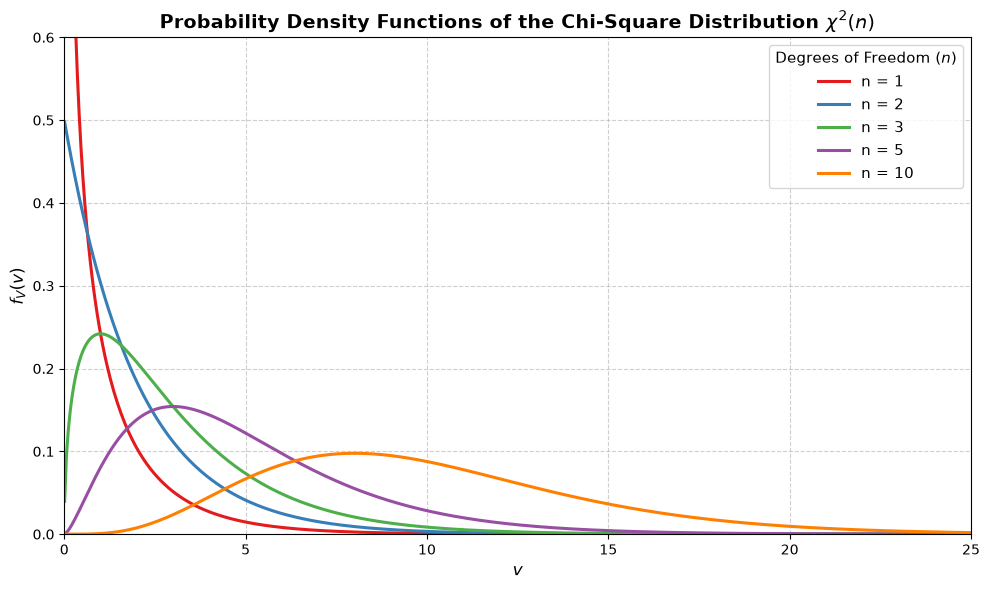

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Set up grid and degrees of freedom
v = np.linspace(0.01, 25, 500)
df_values = [1, 2, 3, 5, 10]
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

plt.figure(figsize=(10, 6))

for df, color in zip(df_values, colors):
    pdf = chi2.pdf(v, df)
    plt.plot(v, pdf, label=f'n = {df}', color=color, lw=2.2)

plt.title('Probability Density Functions of the Chi-Square Distribution $\chi^2(n)$', fontsize=14, fontweight='bold')
plt.xlabel('$v$', fontsize=12)
plt.ylabel('$f_V(v)$', fontsize=12)
plt.ylim(0, 0.6)
plt.xlim(0, 25)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Degrees of Freedom ($n$)', fontsize=11, title_fontsize=11)
plt.tight_layout()
plt.show()